# Soccer Wage Efficiency and Mispricing #
### Course: CS418 - Introduction to Data Science ###
### Team: Beyond the Bears ###
#### Members: Humza Bukhari, Shivansh Amba, Daniel Chavez, Yaw Asiamah, M. Abdullah Shahzad ####

The English Premier League is one of the most financially powerful sports competitions in the world, with clubs collectively spending over £3 billion annually on player wages. Yet despite this enormous financial commitment, salary allocation across players remains deeply uneven — and often difficult to justify on performance alone. Some players command wages that far exceed their on-pitch contributions, while others who consistently deliver elite statistics remain comparatively underpaid. This disconnect raises a fundamental question at the intersection of sports analytics and labor economics: are Premier League clubs efficiently pricing their talent?

This project, Soccer Wage Efficiency and Mispricing, answers that question through a data-driven lens. We integrate detailed player performance statistics from Sofascore with contract and salary data from Capology to construct a dataset spanning over 2,500 player-seasons across five Premier League seasons (2020-21 through 2024-25) and 100+ performance features. Using this merged dataset, we train a machine learning salary prediction model — incorporating per-90 performance metrics, age, playing time, position, and club fixed effects — to estimate what each player should earn based on their measurable on-pitch contributions. We compare two modeling approaches (Lasso regression and XGBoost) under cross-validation grouped by player to ensure honest evaluation. Players whose actual wages deviate significantly from model predictions are flagged as potentially overvalued or undervalued, producing a ranked list of the most over- and underpaid players in each position.

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import ScraperFC as sfc
import numpy as np
import time
import difflib
import xgboost

# Data Retrieval, Cleaning, and Transformation #

### ScraperFC ###
SCraperFC is a Python Library made a couple of years ago that makes extracting data from popular football stat websites easy and free.

### Capology ###
Capology is a website that provides comprehensive estimates of professional football player salaries and club financial data. We are going to use it to gather the player salary data.

Data is taken directedly from the html files through ScraperFC and turned into a dataframe. Unnecessary or redundant columns (country of origin, weekly pay, etc.) are removed, the yearly pay column is converted from a string (since it is taken from an html file) to a double for calculations, and the column labels are renamed for clairity.

Data is taken from the 5 previous seasons (to get a wide variety of data but avoid having to add inflation calculations). Each season is processed separatedly, has a season column added, and then added to one large final dataframe.

In [3]:
# Import functions
from scraper_fuctions import scrape_capology_multiple_seasons

# Define seasons to scrape
seasons_to_scrape = ['2024-25', '2023-24', '2022-23', '2021-22', '2020-21']

# Run scraper
capology_df = scrape_capology_multiple_seasons(seasons = seasons_to_scrape, sleep_time = 10)

# Display the results
if capology_df is not None:
    display(capology_df.head())
    print(f"\nTotal entries in dataset: {len(capology_df)}")

Scraping data for the 2024-25 season...
Changed currency to eur.
  -> Success! 749 players scraped.
  -> Sleeping for 10 seconds...

Scraping data for the 2023-24 season...
Changed currency to eur.
  -> Success! 559 players scraped.
  -> Sleeping for 10 seconds...

Scraping data for the 2022-23 season...
Changed currency to eur.
  -> Success! 535 players scraped.
  -> Sleeping for 10 seconds...

Scraping data for the 2021-22 season...
Changed currency to eur.
  -> Success! 506 players scraped.
  -> Sleeping for 10 seconds...

Scraping data for the 2020-21 season...
Changed currency to eur.
  -> Success! 513 players scraped.
  -> Sleeping for 10 seconds...

Scraping complete! Capology DataFrame created.


,Season,Player,Salary (EUR),Position,Age,Club
0,2024-25,Erling Haaland,31857680.0,F,24,Manchester City
1,2024-25,Kevin De Bruyne,24272518.0,F,33,Manchester City
2,2024-25,Mohamed Salah,24272518.0,F,32,Liverpool
3,2024-25,Virgil van Dijk,21238454.0,D,33,Liverpool
4,2024-25,Casemiro,21238454.0,M,32,Manchester United



Total entries in dataset: 2862


### SofaScore ###
SofaScore is a premier live score and sports analytics platform that provides real-time data, detailed statistics, and unique player ratings. We are going to use it to gather specific player data, it has 110 unique stats. Originally in the proposal, we were going to use FBRef for player stats. This change was made since Sofascore had a much more vast collection of stats, while FBref only had basic stats that only applied to offensive players (goals and assists). The SofaScore data had 100 more columns that show stats for all different positions (offensive, midfield, defensive, and goalies), which will help us gauge the performance of different types of players.

Data is taken from the SofaScore API through ScraperFC and turned into a dataframe. Unneccessary or redundant columns (team, player_id, etc.) are removed and its season is reformated to match the syntax that Capology used (to make merging easier later).

Data is taken from the 5 previous seasons (to match Capology data). Each season is processed separatedly, has a season column added, and then added to one large final dataframe. After all seasons have combined, any columns with null values are removed (to account for different stats being recorded each season and prevent conclusion that ignore a season).

In [4]:
# Import functions
from scraper_fuctions import scrape_sofascore_multiple_seasons

# Run scraper
sofa_df = scrape_sofascore_multiple_seasons(seasons = seasons_to_scrape, sleep_time = 10)

# Display the results
if sofa_df is not None:
    display(sofa_df[['Season', 'Player', 'rating']].head())
    print(f"\nTotal entries in dataset: {len(sofa_df)}")

Scraping Sofascore data for the 2024-25 season (API format: 24/25)...
Running
  -> Success! 562 players scraped. Columns: 111
  -> Sleeping for 10 seconds...

Scraping Sofascore data for the 2023-24 season (API format: 23/24)...
  -> Success! 570 players scraped. Columns: 112
  -> Sleeping for 10 seconds...

Scraping Sofascore data for the 2022-23 season (API format: 22/23)...
  -> Success! 554 players scraped. Columns: 110
  -> Sleeping for 10 seconds...

Scraping Sofascore data for the 2021-22 season (API format: 21/22)...
  -> Success! 538 players scraped. Columns: 107
  -> Sleeping for 10 seconds...

Scraping Sofascore data for the 2020-21 season (API format: 20/21)...
  -> Success! 524 players scraped. Columns: 106
  -> Sleeping for 10 seconds...

Scraping complete! Sofascore DataFrame created.


,Season,Player,rating
0,2024-25,Neto,7.85
1,2024-25,Mohamed Salah,7.78
2,2024-25,Cole Palmer,7.63
3,2024-25,Mark Travers,7.62
4,2024-25,Bruno Fernandes,7.62



Total entries in dataset: 2748


In [5]:
print(sofa_df.columns.tolist())

['Season', 'accurateChippedPasses', 'accurateCrosses', 'accurateCrossesPercentage', 'accurateFinalThirdPasses', 'accurateLongBalls', 'accurateLongBallsPercentage', 'accurateOppositionHalfPasses', 'accurateOwnHalfPasses', 'accuratePasses', 'accuratePassesPercentage', 'aerialDuelsWon', 'aerialDuelsWonPercentage', 'aerialLost', 'appearances', 'assists', 'attemptPenaltyMiss', 'attemptPenaltyPost', 'attemptPenaltyTarget', 'bigChancesCreated', 'bigChancesMissed', 'blockedShots', 'cleanSheet', 'clearances', 'countRating', 'crossesNotClaimed', 'directRedCards', 'dispossessed', 'dribbledPast', 'duelLost', 'errorLeadToGoal', 'errorLeadToShot', 'fouls', 'freeKickGoal', 'goalConversionPercentage', 'goals', 'goalsAssistsSum', 'goalsConceded', 'goalsConcededInsideTheBox', 'goalsConcededOutsideTheBox', 'goalsFromInsideTheBox', 'goalsFromOutsideTheBox', 'groundDuelsWon', 'groundDuelsWonPercentage', 'headedGoals', 'highClaims', 'hitWoodwork', 'inaccuratePasses', 'interceptions', 'keyPasses', 'leftFootG

### Merging the Dataframes ###
The two data frames are combined on player name and season.

Difflab is a python library that is used to match up the player names between the two different dataframe (to account for naming differeneces like accents or capitalization). Seasons titles are already normalized across the dataframes.

In [6]:
# Import merge function
from merge_functions import build_master_dataset

# Build the final dataset
combined_df = build_master_dataset(capology_df, sofa_df)

# Display the results
print(f"\nTotal Rows: {len(combined_df)}")
print(f"Total Columns: {len(combined_df.columns)}")
display(combined_df.head())

Standardizing Capology player names to match Sofascore...
Executing Final Inner Merge...
Merge Complete!

Total Rows: 2405
Total Columns: 106


,Season,Player,Salary (EUR),Position,Age,Club,accurateChippedPasses,accurateCrosses,accurateCrossesPercentage,accurateFinalThirdPasses,...,totalLongBalls,totalOppositionHalfPasses,totalOwnHalfPasses,totalPasses,totalRating,totalShots,totwAppearances,touches,wasFouled,yellowCards
0,2024-25,Erling Haaland,31857680.0,F,24,Manchester City,5,1,33.33,125,...,3,273,105,375,225.3,108,4,696,13,2
1,2024-25,Kevin De Bruyne,24272518.0,F,33,Manchester City,39,38,26.21,473,...,53,975,198,1028,207.3,57,6,1425,18,2
2,2024-25,Mohamed Salah,24272518.0,F,32,Liverpool,55,17,21.52,471,...,52,1017,217,1155,295.7,130,13,1864,39,1
3,2024-25,Virgil van Dijk,21238454.0,D,33,Liverpool,107,0,0.00,395,...,276,1264,1659,2922,269.2,27,5,3346,13,5
4,2024-25,Casemiro,21238454.0,M,32,Manchester United,69,8,40.00,193,...,91,532,448,960,172.2,32,2,1298,19,5


# Visualization and insights #

### Average Salary per Position by Season ###

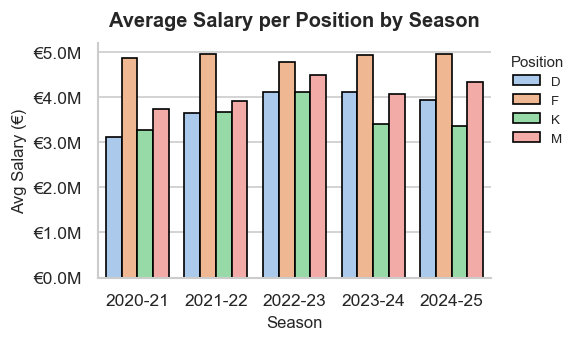

In [7]:
from plotting_functions import plot_avg_salary_by_position
plot_avg_salary_by_position(combined_df)

<div style="font-size:13px; line-height:1.4;">

<h4 style="font-size:15px; margin-bottom:2px;">
Structural biases in wages
</h4>

Forwards consistently show the highest average salaries across all seasons. Midfielders and defenders remain in a mid-range salary band, while goalkeepers consistently receive the lowest wages.

Overall, clubs appear to value attacking output significantly more than defensive contributions, with forwards earning roughly 60% more on average than goalkeepers.

</div>

### Salary Distribution and Outliers by Position ###

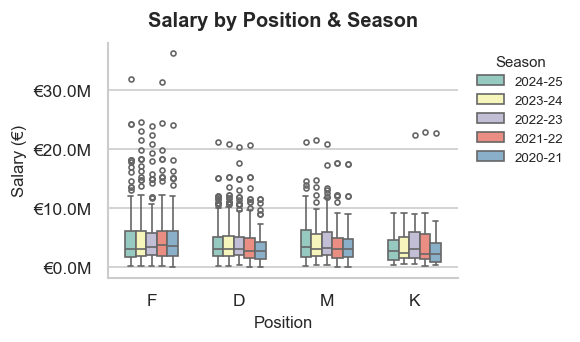

In [8]:
from plotting_functions import plot_salary_boxplot_by_position_and_season
plot_salary_boxplot_by_position_and_season(combined_df)

<div style="font-size:13px; line-height:1.4;">

<h4 style="font-size:15px; margin-bottom:2px;">
Forwards have the highest number of outliers
</h4>

The boxplots show that forwards consistently have the highest and most salary outliers for all seasons. This suggests that clubs are willing to pay more towards forwards.

<h4 style="font-size:15px; margin-bottom:2px;">
Defensive and midfield roles are less extreme and more predictable
</h4>

Defenders and midfielders show fewer extreme salary outliers and generally maintain a more balanced salary distribution. This suggests that clubs value these positions more consistently and avoid excessive spending compared to attacking roles.

<h4 style="font-size:15px; margin-bottom:2px;">
Goalkeepers are the most stable
</h4>

Goalkeepers rarely show outliers, at most two players, reinforcing the idea that even elite goalkeeping performance is less financially rewarded compared to outfield positions. This also signifies that clubs generally agree on goalkeeper salary ranges and are less willing to take financial risks when recruiting keepers.

<h4 style="font-size:15px; margin-bottom:2px;">
Final thoughts
</h4>

Overall, the visualization suggests that football salaries are not only position-dependent but also highly skewed toward attacking roles, where forwards dominate the upper tail of the salary distribution. This indicates a structural bias in how clubs financially value different positions.

</div>


### Salary vs Player Rating ###

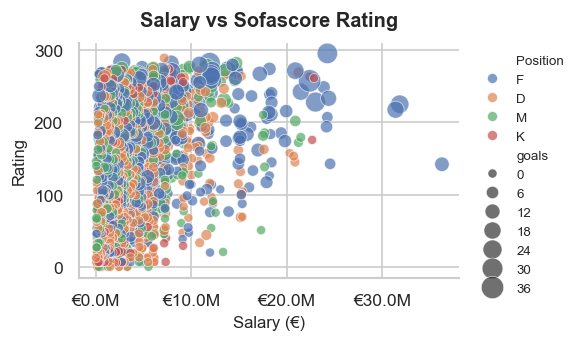

In [9]:
from plotting_functions import plot_salary_vs_rating
plot_salary_vs_rating(combined_df)

<div style="font-size:14px; line-height:1.4;">

<h4 style="font-size:14px; margin-bottom:2px;">
Weak trends in Pay-Performance Relationship
</h4>

With the wide range in salaries, there is an inconsistent trend with players SofaScore rating and salaries. This would suggest that player performance scores are not a strong indicator of predicting the salaries of the players.

<h4 style="font-size:14px; margin-bottom:2px;">
Bias in Salaries
</h4>

Players who play position forward have higher clusters of salaries. Even though defenders and midfielders show more higher stats than a forward their salaries are more spread towards the lower side. This would present systemic positional bias amongst the salaries of the players, where Forwards are more favored financially then any other position when it comes to salaries.

<h4 style="font-size:14px; margin-bottom:2px;">
Undervalued High Performers
</h4>

There seems to be alot of players with high SofaScore ratings but relatively low salaries. These players present the most value dollar, but it seems clubs are mismanaging and overvaluing, "superstars."

</div>

# Machine Learning #
We frame this as a **regression problem on log-transformed salary**. The log transformation is essential here: Premier League wages are heavily right-skewed (Erling Haaland earns roughly 60× a squad player), and modeling raw salary would let a handful of superstars dominate the fit. Working in log-space makes our residuals interpretable as percent deviation — a residual of +0.4 means a player earns roughly 49% more than the model predicts, which is exactly the "mispricing" signal we want to surface.

### Pipeline overview ###

1. **Data preparation** — engineering per-90 stats so a player who logged 3,000 minutes is comparable to one who logged 800; one-hot encoding position; and grouping the 20 Premier League clubs into three spending tiers (Big Six, established, and lower) to capture how much of a player's wage comes from *who they play for* rather than *how they play*.

2. **Model training and comparison** — we fit two models with identical features and identical cross-validation. **Lasso regression** (linear with L1 regularization) provides interpretable coefficients and built-in feature selection. **XGBoost** (gradient-boosted trees) provides a non-linear comparison that can capture interactions Lasso cannot. We pick the winner based on cross-validated MAE on log-salary.

3. **Honest validation** — both models use **5-fold cross-validation grouped by player**. This is critical: a naive random split would put Salah-2022 in training and Salah-2023 in test, letting the model "memorize" rather than generalize. By keeping all of one player's seasons together in a single fold, we test whether our predictions hold up for *new players* the model has never seen.

4. **Mispricing analysis** — for each player, we compute the gap between actual and predicted salary (the residual). Averaging residuals across multiple seasons stabilizes the signal — a single bad season won't flag someone as overpaid. The output is a ranked list of the most overpaid and most underpaid players in each position, which is the headline deliverable of this project.

### What we expect to find ###

Our hypothesis is that performance metrics, age, and club tier explain a meaningful portion of salary variance — but not all of it. The unexplained portion is exactly where mispricing lives: contract timing, marketability, off-pitch brand value, and front-office misjudgments are all factors our model cannot see. The residuals from a well-specified salary model give us a principled way to surface those gaps.

Preparing data features...
Training Lasso model...

--- Top 10 Features Driving Salary (Lasso) ---
club_tier_tier_lower              -0.514
club_tier_tier_mid                -0.263
Age                                0.181
rating                             0.131
goals_per_90                       0.065
minutesPlayed                      0.064
accuratePassesPercentage_per_90    0.048
matchesStarted_per_90              0.024
totalShots_per_90                  0.021
pos_M                              0.017
dtype: float64
----------------------------------------
Training XGBoost model...

--- Top 10 Features Driving Salary (XGBoost) ---
club_tier_tier_lower               0.562
club_tier_tier_mid                 0.215
Age                                0.029
rating                             0.025
totalShots_per_90                  0.015
clearances_per_90                  0.014
minutesPlayed                      0.014
goalConversionPercentage_per_90    0.013
keyPasses_per_90               

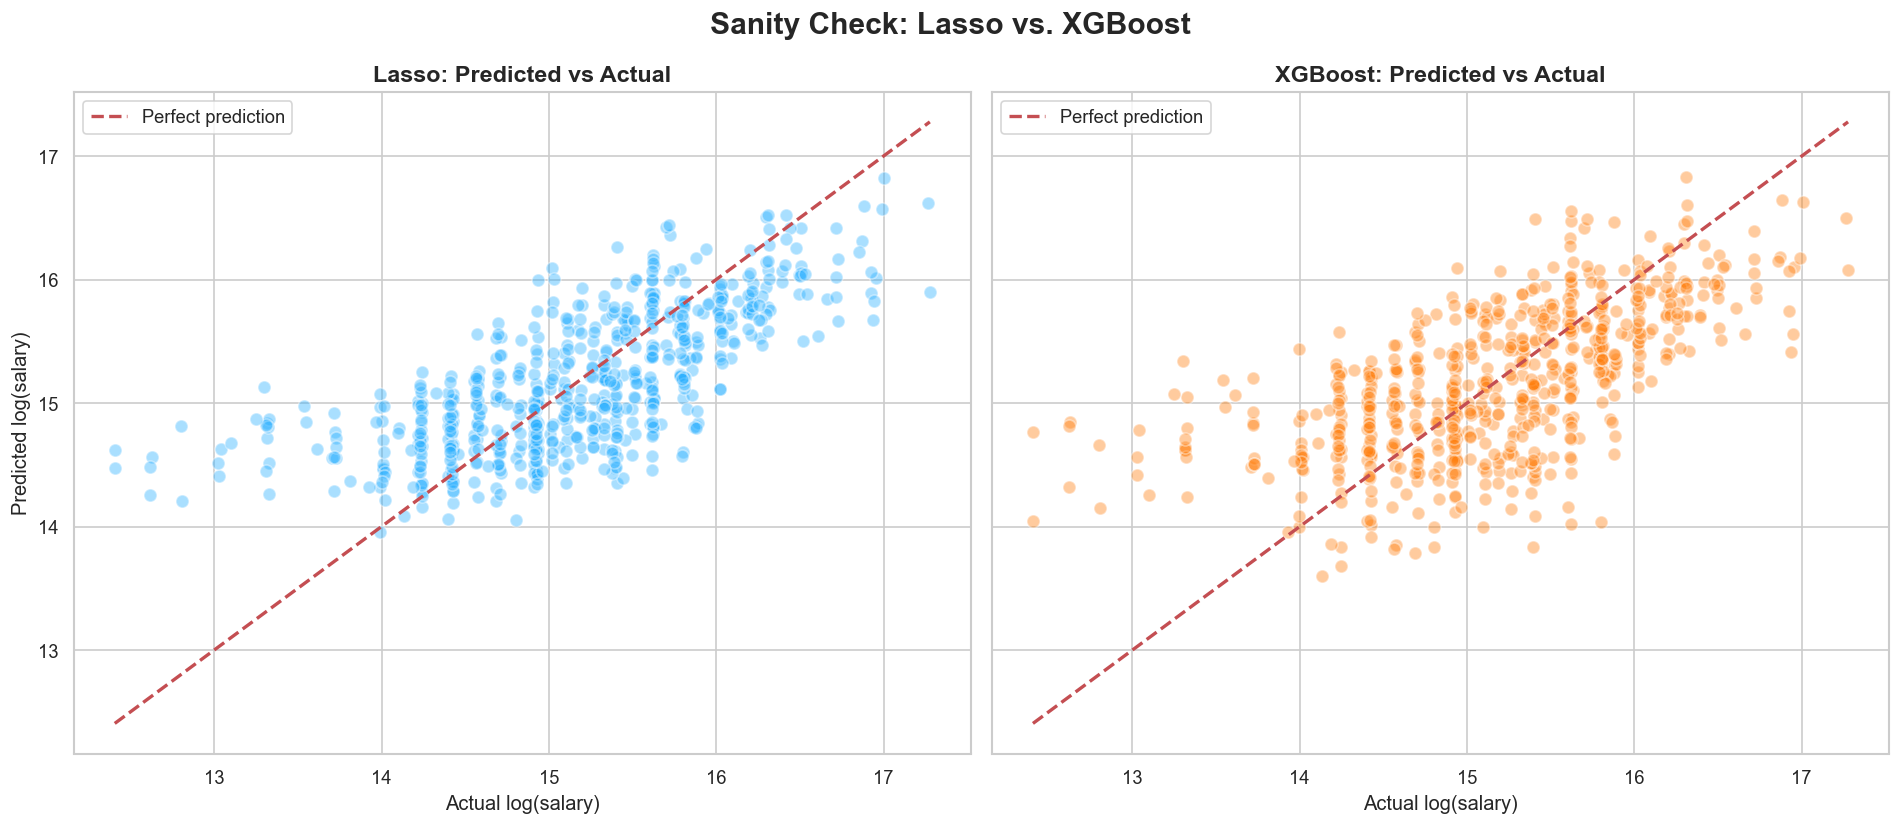

In [10]:
# Import ML functions
from ml_functions import (prepare_data, train_lasso_model, train_xgboost_model, compare_models_and_evaluate, plot_ml_sanity_check)

# Extract and format the data
df_model, X, y, groups, cv = prepare_data(combined_df)

# Train both models independently
lasso_predictions = train_lasso_model(X, y, groups, cv)
xgb_predictions = train_xgboost_model(X, y, groups, cv)

# Compare the results and calculate player mispricing
final_results_df = compare_models_and_evaluate(df_model, y, lasso_predictions, xgb_predictions)

# Visualize the outcome
plot_ml_sanity_check(final_results_df)

### Mispricing Analysis ###

With the data from the model, we will deduce the overpaid and underpaid players by comparing their what the model thought they should earn versus what they acutally earn. There weren't enough keeper entries that met the criteria (over 25 games played) so that we could make a make a top 10 under- and overpaid.

In [11]:
from ml_functions import analyze_mispricing
mispricing_summary = analyze_mispricing(final_results_df)


   MISPRICING ANALYSIS: OVERPAID VS UNDERPAID 

  FORWARDS

TOP 10 OVERPAID:
            Player Position  seasons Actual Predicted Deviation
    Erling Haaland        F        3 €25.8M     €8.8M     +196%
     Wilfried Zaha        F        3  €7.9M     €2.8M     +181%
       Kai Havertz        F        2 €16.1M     €6.5M     +151%
     Lucas Paquetá        F        2  €9.2M     €4.1M     +127%
   Marcus Rashford        F        3 €14.2M     €6.3M     +125%
      Raúl Jiménez        F        2  €6.1M     €3.2M      +99%
Morgan Gibbs-White        F        3  €4.8M     €2.5M      +93%
Gabriel Martinelli        F        2 €10.8M     €6.7M      +65%
    Bernardo Silva        F        3 €15.3M     €9.4M      +60%
     Jack Harrison        F        3  €3.3M     €2.1M      +60%

TOP 10 UNDERPAID:
          Player Position  seasons Actual Predicted Deviation
   Dwight McNeil        F        4  €0.9M     €2.9M      -72%
      Ivan Toney        F        2  €1.2M     €3.4M      -64%
       Luis D

# Reflection # 
- What is hardest part of the project that you’ve encountered so far?  
    - Testing the data retrieval and cleaning was challenging, because the websites we scraped have heavy anti-bot protection. We needed to add sleep timers between requests to prevent getting blocked, making testing and deployment time-consuming. We also ran into issues mid-project when Capology changed their schema, requiring us to rework parts of our scraper.

- Going forward, what are the current biggest problems you’re facing?  
    - Building a satistying machine learning model was difficult given the 100+ stats available. Narrowing down which stats work best for which position required significant trial and error, especially for midfielders who contribute to both offense and defense. We also found that salaries are heavily influenced by factors our model can't see, such as reputation, marketability, contract length and negotiation power.

- Given your initial exploration of the data, is it worth proceeding with your
project, why? If not, how are you going to change your project and why do
you think it’s better than your current results?  
    - Absolutely. Our LASSO model achieves R^2 = 0.499 and identifies clear mispricing patterns across all positions. The visualizations confirm structural salary biases that go beyond just performance. We are confident that the model provides a genuine data-drivem lens for evaluating wage efficiency in the EPL.

## Next Steps ##
- What you plan to accomplish in the next month and how you plan to evaluate whether your project achieved the goals you set for it.
    #### Position Specific Models ####
    - We want to train separate Lasso models per positions (F/M/D/K) since a defensive midfielder is paid very differently from an attacking midfielder. This should reduce out typical error.

    #### Expand to Other Leagues ####
    - One question that came across was maybe this bias was limited to the EPL. To test this, we want to test whether the positional salary bias we found in EPL exists in other major leagues or not.

    #### Injury adjustment ####
    - Many players were flagged during the season where significant minutes were missed due to injury so those seasons are not mistakenly labeled as overpaid.

    #### Add Transfer Fee Data ####
    - Incorporate trasnfer fees as an additional feature since clubs often pay higher wages to justify large trasnfer investment.

    #### Scouting Tool ####
    - We want to create an interactive dashboard with the ability for clubs or scouts to input a budget and a position and get the top 5 statistically undervalued players available in the market for their team. This interactive dashboard would also include a club-level wage efficiency explorer where we can filter by team, position, and season for clubs to see if their overpaying or underpaying.


    #### Real-Time Tracking ####
    - We would want to try a new feature where we hook into live SofaScore data to update mispricing scores throughout the season as player form changes.